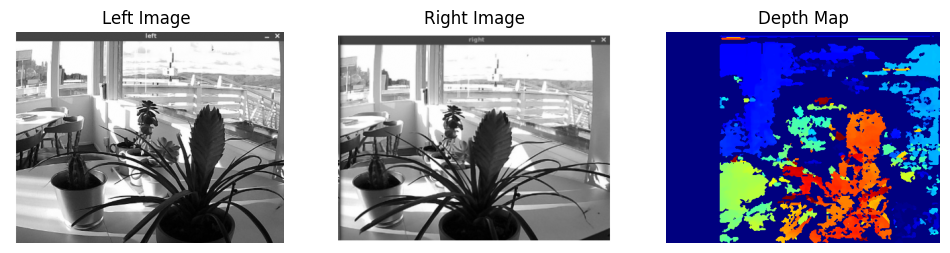


===== DEPTH SUMMARY =====
Avg Depth : 65.24
Min Depth : 12.66
Max Depth : 1777.78



In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load stereo images (use FULL PATH)
imgL = cv2.imread("C:/Users/lenovo/Desktop/IPCV/images/left.png")
imgR = cv2.imread("C:/Users/lenovo/Desktop/IPCV/images/right.png")

# Check if loaded
if imgL is None or imgR is None:
    print("❌ Error: Images not found")
    exit()

# Convert to grayscale
imgL = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
imgR = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)

# Resize right image
imgR = cv2.resize(imgR, (imgL.shape[1], imgL.shape[0]))

# Create StereoSGBM object
stereo = cv2.StereoSGBM_create(
    minDisparity=0,
    numDisparities=16 * 5,  # must be multiple of 16
    blockSize=5,
    P1=8 * 3 * 5**2,
    P2=32 * 3 * 5**2,
    uniquenessRatio=10,
    speckleWindowSize=100,
    speckleRange=32
)

# Compute disparity
disparity = stereo.compute(imgL, imgR).astype(np.float32)

# 🔥 IMPORTANT FIX (OpenCV scaling)
disparity = disparity / 16.0

# Normalize for display
disp = cv2.normalize(disparity, None, 0, 255, cv2.NORM_MINMAX)
disp = np.uint8(disp)

# Depth estimation (inverse relation)
depth = np.zeros_like(disparity, dtype=np.float32)
depth[disparity > 0] = 1000 / (disparity[disparity > 0])

# Display images
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Left Image")
plt.imshow(imgL, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Right Image")
plt.imshow(imgR, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Depth Map")
plt.imshow(disp, cmap='jet')
plt.axis('off')

plt.show()

# Depth statistics
valid_depth = depth[depth > 0]

print("\n===== DEPTH SUMMARY =====")
print(f"Avg Depth : {np.mean(valid_depth):.2f}")
print(f"Min Depth : {np.min(valid_depth):.2f}")
print(f"Max Depth : {np.max(valid_depth):.2f}")
print("=========================\n")